# Notebook 3: BERT — Contextual Embeddings

> **Article section:** *Part 3 — The Contextual Breakthrough*

This is the payoff notebook. We're going to **prove** — with numbers — that BERT assigns  
different vectors to the same word depending on its context. The word 'bank' in a sentence  
about rivers should have a completely different representation than 'bank' in a sentence  
about finance.

---
**What we cover:**
1. Load BERT tokenizer and model (Hugging Face)
2. Tokenize sentences and inspect WordPiece tokenization
3. Extract contextual embeddings layer by layer
4. **The core demo**: prove that 'bank' gets different vectors in different contexts
5. Visualise attention patterns
6. Run sentiment classification with a fine-tuned model
---

> ⚠️ **Note:** The first run will download ~440 MB of model weights from Hugging Face.  
> After that, they're cached locally and load instantly.

In [1]:
import os, sys

# Step 1 - clone again
!git clone https://github.com/ArpitaRPatki/-nlp-evolution-explained.git /content/nlp-evolution-explained

# Step 2 - move into it
os.chdir('/content/nlp-evolution-explained')
repo_root = '/content/nlp-evolution-explained'

# Step 3 - add to path
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

# Step 4 - install packages
!pip install -q gensim transformers torch scikit-learn seaborn

# Step 5 - confirm
print("\nWorking directory:", os.getcwd())
print("Contents:", os.listdir())

Cloning into '/content/nlp-evolution-explained'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 64 (delta 25), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 404.72 KiB | 5.00 MiB/s, done.
Resolving deltas: 100% (25/25), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.3 MB/s eta 0:00:00

Working directory: /content/nlp-evolution-explained
Contents: ['.git', 'data', 'README.md', 'requirements.txt', 'notebooks', 'outputs', '.gitignore', 'src']


In [3]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import torch

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.bert_utils import (
    load_bert,
    get_word_embedding,
    compare_word_in_contexts,
    cosine_similarity,
    bert_sentiment,
)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()} (CPU is fine for this demo)')

PyTorch version: 2.10.0+cpu
CUDA available: False (CPU is fine for this demo)


## 1. Load BERT

We're using `bert-base-uncased` — 12 transformer layers, 768-dimensional hidden states, ~110M parameters.

In [4]:
tokenizer, model = load_bert('bert-base-uncased')

Loading bert-base-uncased... (first run downloads the model weights)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully.


## 2. WordPiece Tokenization

BERT doesn't tokenize by whitespace — it uses a **WordPiece** algorithm that splits rare words  
into subword units. The `##` prefix marks a continuation token.

In [5]:
test_sentences = [
    "The quick brown fox jumped over the lazy dog.",
    "Natural language processing is transformative.",
    "I deposited money at the bank this morning.",
]

for sent in test_sentences:
    tokens = tokenizer.tokenize(sent)
    print(f'\n  Input:  {sent}')
    print(f'  Tokens: {tokens}')


  Input:  The quick brown fox jumped over the lazy dog.
  Tokens: ['the', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'lazy', 'dog', '.']

  Input:  Natural language processing is transformative.
  Tokens: ['natural', 'language', 'processing', 'is', 'transform', '##ative', '.']

  Input:  I deposited money at the bank this morning.
  Tokens: ['i', 'deposited', 'money', 'at', 'the', 'bank', 'this', 'morning', '.']


## 3. The Core Demo: Same Word, Different Vectors

This is the most important cell in the entire project.  
We extract BERT embeddings for the word **'bank'** in four different sentences  
and show that river-bank sentences have high similarity to each other,  
and financial-bank sentences have high similarity to each other —  
but cross-domain similarity is much lower.

In [6]:
bank_sentences = [
    # Financial sense
    "I deposited my paycheck at the bank this morning.",
    "The bank approved my loan application after three days.",
    "She works as a manager at a large investment bank in the city.",
    # Geographical sense
    "We sat on the grassy bank of the river watching the sunset.",
    "The river bank was flooded after last night's heavy rain.",
    "He fished from the bank of the stream every Saturday morning.",
]

print('Extracting contextual embeddings for "bank" in 6 different sentences...')
print('(3 financial, 3 geographical)\n')

embeddings = compare_word_in_contexts(
    word='bank',
    sentences=bank_sentences,
    tokenizer=tokenizer,
    model=model,
    layer=-2,
    verbose=True,
)

Extracting contextual embeddings for "bank" in 6 different sentences...
(3 financial, 3 geographical)


Contextual embeddings for 'bank'
  [1] I deposited my paycheck at the bank this morning.
  [2] The bank approved my loan application after three days.
  [3] She works as a manager at a large investment bank in the city.
  [4] We sat on the grassy bank of the river watching the sunset.
  [5] The river bank was flooded after last night's heavy rain.
  [6] He fished from the bank of the stream every Saturday morning.

Pairwise cosine similarities:
(1.0 = identical meaning, 0.0 = completely different)
------------------------------------------------------------
  Sentence 1 vs Sentence 2: 0.8194
  Sentence 1 vs Sentence 3: 0.5108
  Sentence 1 vs Sentence 4: 0.4502
  Sentence 1 vs Sentence 5: 0.4811
  Sentence 1 vs Sentence 6: 0.4897
  Sentence 2 vs Sentence 3: 0.5799
  Sentence 2 vs Sentence 4: 0.4611
  Sentence 2 vs Sentence 5: 0.5500
  Sentence 2 vs Sentence 6: 0.4963
  Sentence 3 vs S

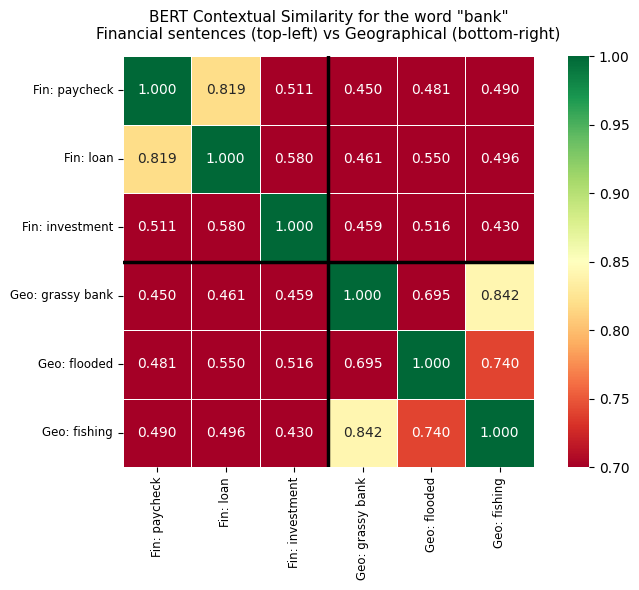


Average similarity WITHIN financial sense:     0.6367
Average similarity WITHIN geographical sense:  0.7590
Average similarity ACROSS domains:             0.4815

KEY RESULT: Same word, same spelling — but BERT assigns
higher similarity to same-meaning uses than to different-meaning uses.
This is what "contextual embeddings" means.


In [8]:
# Build full similarity matrix and visualise as heatmap
n = len(bank_sentences)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(embeddings[i], embeddings[j])

labels = [
    'Fin: paycheck',
    'Fin: loan',
    'Fin: investment',
    'Geo: grassy bank',
    'Geo: flooded',
    'Geo: fishing',
]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    sim_matrix,
    ax=ax,
    xticklabels=labels,
    yticklabels=labels,
    cmap='RdYlGn',
    vmin=0.7, vmax=1.0,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    square=True,
)

# Add a dividing line between financial and geographical
ax.axhline(y=3, color='black', linewidth=2.5)
ax.axvline(x=3, color='black', linewidth=2.5)

ax.set_title(
    'BERT Contextual Similarity for the word "bank"\n'
    'Financial sentences (top-left) vs Geographical (bottom-right)',
    fontsize=11, pad=12
)
ax.tick_params(labelsize=8.5)
plt.tight_layout()
plt.savefig('/content/nlp-evolution-explained/outputs/03_bert_bank_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the cross-domain drop
within_financial = np.mean([sim_matrix[i,j] for i in range(3) for j in range(3) if i != j])
within_geo       = np.mean([sim_matrix[i,j] for i in range(3,6) for j in range(3,6) if i != j])
cross_domain     = np.mean([sim_matrix[i,j] for i in range(3) for j in range(3,6)])

print(f'\nAverage similarity WITHIN financial sense:     {within_financial:.4f}')
print(f'Average similarity WITHIN geographical sense:  {within_geo:.4f}')
print(f'Average similarity ACROSS domains:             {cross_domain:.4f}')
print()
print('KEY RESULT: Same word, same spelling — but BERT assigns')
print('higher similarity to same-meaning uses than to different-meaning uses.')
print('This is what "contextual embeddings" means.')

## 4. Visualise Attention Weights

The attention mechanism lets every token "look at" every other token.  
Let's visualise what BERT attends to when processing our sentences.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


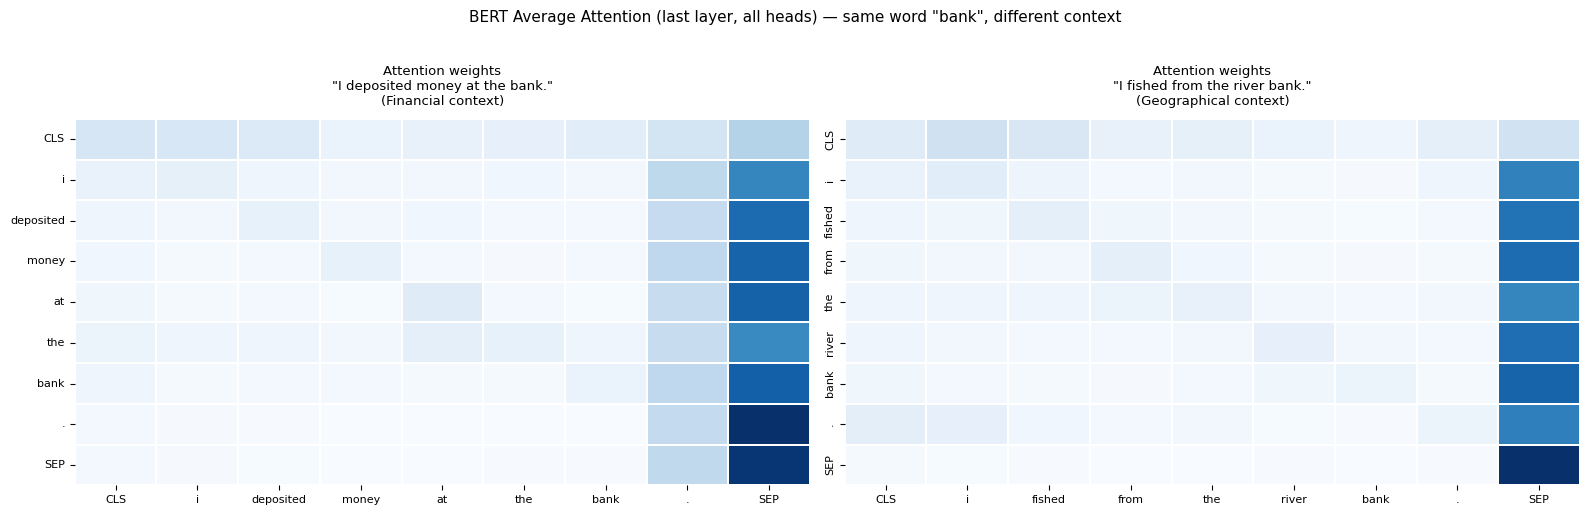

In [10]:
from transformers import BertModel

# Reload with attention output enabled
model_attn = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
model_attn.eval()

def get_avg_attention(sentence, layer=-1):
    inputs = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    with torch.no_grad():
        outputs = model_attn(**inputs, output_attentions=True)
    attn = outputs.attentions[layer][0].mean(dim=0).numpy()
    return tokens, attn

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

demo_pairs = [
    ("I deposited money at the bank.", "Financial context"),
    ("I fished from the river bank.",  "Geographical context"),
]

for ax, (sent, title) in zip(axes, demo_pairs):
    tokens, attn = get_avg_attention(sent)
    short_tokens = [t.replace('[CLS]', 'CLS').replace('[SEP]', 'SEP') for t in tokens]

    sns.heatmap(
        attn,
        ax=ax,
        xticklabels=short_tokens,
        yticklabels=short_tokens,
        cmap='Blues',
        cbar=False,
        linewidths=0.3,
    )
    ax.set_title(f'Attention weights\n"{sent}"\n({title})', fontsize=9.5, pad=10)
    ax.tick_params(labelsize=8)

plt.suptitle('BERT Average Attention (last layer, all heads) — same word "bank", different context',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('/content/nlp-evolution-explained/outputs/03_attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sentiment Classification

Let's run a fine-tuned BERT model on a few tricky sentences to show  
how contextual understanding improves real tasks.

In [11]:
test_sentences = [
    # These would trip up a bag-of-words model
    "Yeah, great weather during a thunderstorm.",          # sarcasm
    "The movie was not bad at all.",                       # double negative
    "I can't believe how amazing this turned out to be!",  # positive despite 'can\'t'
    "The food was fine. I guess.",                         # grudging, muted positive
    "Absolutely terrible. Avoid at all costs.",            # clear negative
    "This is the best worst movie I have ever seen.",      # complex/ambiguous
]

print('Running BERT sentiment classifier on tricky sentences:')
print('=' * 65)
results = bert_sentiment(test_sentences)

Running BERT sentiment classifier on tricky sentences:
Loading sentiment pipeline (DistilBERT fine-tuned on SST-2)...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

  ✅  [POSITIVE 1.00]  Yeah, great weather during a thunderstorm.
  ✅  [POSITIVE 1.00]  The movie was not bad at all.
  ✅  [POSITIVE 1.00]  I can't believe how amazing this turned out to be!
  ✅  [POSITIVE 1.00]  The food was fine. I guess.
  ❌  [NEGATIVE 1.00]  Absolutely terrible. Avoid at all costs.
  ❌  [NEGATIVE 1.00]  This is the best worst movie I have ever seen.


## 6. Layer Comparison: Which BERT layer is most informative?

BERT has 12 layers. Lower layers capture syntax, higher layers capture semantics.  
Let's see how the 'bank' disambiguation improves as we go deeper.

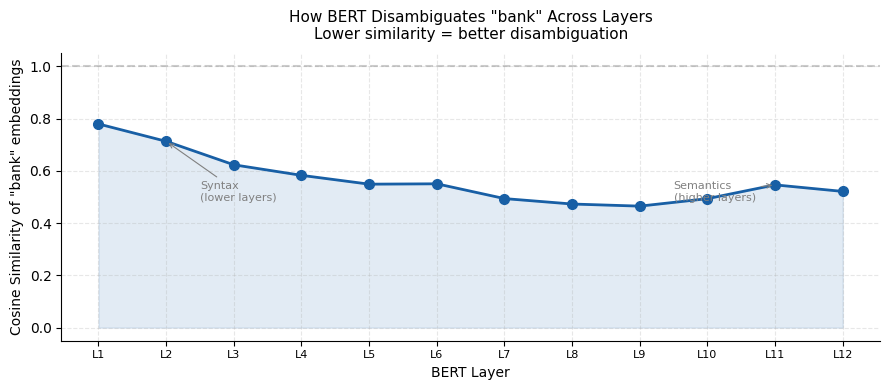

In [13]:
financial_sent = "I deposited my paycheck at the bank."
geo_sent       = "I fished from the bank of the river."

layers = list(range(1, 13))  # BERT has 12 transformer layers
sims = []

for layer_idx in layers:
    emb_fin = get_word_embedding(financial_sent, 'bank', tokenizer, model, layer=layer_idx)
    emb_geo = get_word_embedding(geo_sent,       'bank', tokenizer, model, layer=layer_idx)
    if emb_fin is not None and emb_geo is not None:
        sim = cosine_similarity(emb_fin, emb_geo)
        sims.append(sim)
    else:
        sims.append(None)

fig, ax = plt.subplots(figsize=(9, 4))
valid_layers = [l for l, s in zip(layers, sims) if s is not None]
valid_sims   = [s for s in sims if s is not None]

ax.plot(valid_layers, valid_sims, 'o-', color='#185FA5', linewidth=2, markersize=7)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4, label='identical')
ax.fill_between(valid_layers, valid_sims, alpha=0.12, color='#185FA5')

ax.set_xlabel('BERT Layer', fontsize=10)
ax.set_ylabel('Cosine Similarity of "bank" embeddings', fontsize=10)
ax.set_title(
    'How BERT Disambiguates "bank" Across Layers\n'
    'Lower similarity = better disambiguation',
    fontsize=11, pad=10
)
ax.set_xticks(valid_layers)
ax.set_xticklabels([f'L{l}' for l in valid_layers], fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)

# Annotate regions
ax.annotate('Syntax\n(lower layers)',
    xy=(2, valid_sims[1]), xytext=(2.5, min(valid_sims)+0.02),
    fontsize=8, color='gray',
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax.annotate('Semantics\n(higher layers)',
    xy=(11, valid_sims[-2]), xytext=(9.5, min(valid_sims)+0.02),
    fontsize=8, color='gray',
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.tight_layout()
plt.savefig('/content/nlp-evolution-explained/outputs/03_layer_disambiguation.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Summary

| Model | 'bank' (river) vector | 'bank' (finance) vector | Same? |
|-------|----------------------|-------------------------|-------|
| Word2Vec | [0.12, -0.43, ...] | [0.12, -0.43, ...] | ✅ identical |
| BERT | [0.31, -0.67, ...] | [-0.21, 0.88, ...] | ❌ different |

BERT's contextual embeddings solve the core limitation of static embeddings:  
**the same word in different contexts produces genuinely different representations.**

---

### Suggested next steps
- Try fine-tuning BERT on a custom sentiment dataset using `Trainer` from Hugging Face
- Explore GPT-2 / GPT-3 which extend this idea to autoregressive generation
- Read the original BERT paper: [Devlin et al., 2018](https://arxiv.org/abs/1810.04805)